# Q6 code:

In [109]:
import numpy as np

In [252]:
class SimpleNeuralNetwork:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = {}
        self.biases = {}
        
    def initializing_parameters(self, input_dim):
        # Initializing weights and biases for hidden layer (2 neurons)
        self.weights['W1'] = np.random.randn(input_dim, 2) * 0.1
        self.biases['b1'] = np.zeros((1, 2))
        
        # Initializing weights and biases for output layer (1 neuron)
        self.weights['W2'] = np.random.randn(2, 1) * 0.01
        self.biases['b2'] = np.zeros((1, 1))
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def forward(self, X):
        # Forward passing through the network 
        cache = {} # here I'll keep the resulted pre-activations and activations Z1 Z2 A1 A2
        
        # The hidden layer
        Z1 = np.dot(X, self.weights['W1']) + self.biases['b1']
        A1 = self.sigmoid(Z1)
        
        
        Z2 = np.dot(A1, self.weights['W2']) + self.biases['b2']
        A2 = self.sigmoid(Z2)
        cache['Z1'] = Z1
        cache['A1'] = A1
        cache['Z2'] = Z2
        cache['A2'] = A2
        
        return cache
    
    def loss(self, y_true, y_pred):
        # Binary cross-entropy loss
        m = y_true.shape[0]
        loss = -1/m * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss
    
    def backward(self, X, y, cache):
        # Keeping the number of samples
        m = X.shape[0]
        
        # Getting activations from forward pass
        A1 = cache['A1']
        A2 = cache['A2']
        
        # Output layer gradients from the Q5th's derived formulas
        dZ2 = A2 - y
        dW2 = 1/m * np.dot(A1.T, dZ2)
        db2 = 1/m * np.sum(dZ2, axis=0, keepdims=True)
        
        # Hidden layer gradients from the Q5th's derived formulas
        dZ1 = np.dot(dZ2, self.weights['W2'].T) * A1 * (1 - A1)
        dW1 = 1/m * np.dot(X.T, dZ1)
        db1 = 1/m * np.sum(dZ1, axis=0, keepdims=True)
        
        return dW1, db1, dW2, db2
    
    def parameter_updates(self, dW1, db1, dW2, db2):
        # Updating weights and biases using gradient descent
        self.weights['W1'] -= self.learning_rate * dW1
        self.biases['b1'] -= self.learning_rate * db1
        self.weights['W2'] -= self.learning_rate * dW2
        self.biases['b2'] -= self.learning_rate * db2
    
    def fit(self, X, y):
        # Setting the shape of X and y properly to avoid an error and to do the right thing
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        
        self.initializing_parameters(X.shape[1])
        
        for i in range(self.num_iterations):
            # Forward pass
            cache = self.forward(X)
            
            # loss computation
            loss = self.loss(y, cache['A2'])
            
            # Backpropagation
            dW1, db1, dW2, db2 = self.backward(X, y, cache)
            
            # Updating the parameters
            self.parameter_updates(dW1, db1, dW2, db2)
            
            if i % 400 == 0:
                print(f"Iteration {i}, Loss: {loss* 100:.4f}") # Printing loss every 100 iterations
    
    def predict(self, X):
        X = np.array(X)
        cache = self.forward(X)
        predictions = cache['A2'] # taking the probabilities range is 0-1
        return (predictions > 0.5).astype(int) # Thresholding at 0.5 to create binary predictions

In [127]:
if __name__ == "__main__":
    # Creating reproducible synthetic dataset for binary classification
    np.random.seed(42)
    X = np.random.randn(100, 2)
    # XOR problem simulation (which requires more than 1 neurons since it is not linearly separable)
    y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0).astype(int)
    

    model = SimpleNeuralNetwork(learning_rate = 0.8, num_iterations=5000) # I have experimented with a lot of alphas and #of iterations 
    model.fit(X, y)                                                     # 78% accuracy is not the end of the world for such a small NN
    predictions = model.predict(X)
    accuracy = np.mean(predictions.flatten() == y) # Compares the proportion of True boolean matches between
    print(f"Accuracy: {accuracy * 100:.2f}%")      # the predictions and the actual values

Iteration 0, Loss: 69.3362
Iteration 400, Loss: 68.5631
Iteration 800, Loss: 62.9994
Iteration 1200, Loss: 52.6416
Iteration 1600, Loss: 49.6853
Iteration 2000, Loss: 48.7410
Iteration 2400, Loss: 48.2224
Iteration 2800, Loss: 47.8910
Iteration 3200, Loss: 47.6531
Iteration 3600, Loss: 47.4683
Iteration 4000, Loss: 47.3172
Iteration 4400, Loss: 47.1891
Iteration 4800, Loss: 47.0779
Accuracy: 78.00%


# Q9 code

In [130]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [221]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [223]:
X_test.shape

(10000, 28, 28)

In [225]:
# Data preprocessing - normalizing pixel values to 0-1 range (from 0-255)
X_train = X_train / 255.0
X_test = X_test / 255.0

In [227]:
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


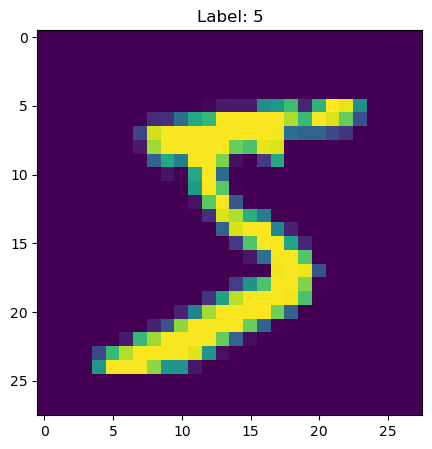

In [233]:
# Checking a sample image
plt.figure(figsize=(5, 5))
plt.imshow(X_train[0])
plt.title(f"Label: {y_train[0]}")
plt.show()

---

## DNN MODEL

In [238]:
dnn_model = Sequential([Flatten(input_shape=(28, 28)),
                        Dense(128, activation='relu'),
                        Dense(32, activation='relu'),
                        Dense(10, activation='softmax')])

In [240]:
dnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [242]:
dnn_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [244]:
# Training the DNN model
dnn_history = dnn_model.fit(X_train, y_train, epochs=25, validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8514 - loss: 0.5074 - val_accuracy: 0.9539 - val_loss: 0.1564
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9617 - loss: 0.1284 - val_accuracy: 0.9641 - val_loss: 0.1198
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9748 - loss: 0.0830 - val_accuracy: 0.9699 - val_loss: 0.0997
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9814 - loss: 0.0604 - val_accuracy: 0.9661 - val_loss: 0.1139
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9851 - loss: 0.0472 - val_accuracy: 0.9704 - val_loss: 0.1084
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9883 - loss: 0.0373 - val_accuracy: 0.9728 - val_loss: 0.1009
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9908 - loss: 0.0278 - val_accuracy: 0.9752 - val_loss: 0.0909
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9931 - loss: 0.0224 - 

In [246]:
dnn_loss, dnn_accuracy = dnn_model.evaluate(X_test, y_test)
print(f"DNN Test Accuracy: {dnn_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step - accuracy: 0.9735 - loss: 0.1535
DNN Test Accuracy: 0.9775


In [248]:
# Calculating accuracy using sklearn (for confirmation)
dnn_predictions = dnn_model.predict(X_test)
dnn_predicted_classes = np.argmax(dnn_predictions, axis=1)
dnn_sklearn_accuracy = accuracy_score(y_test, dnn_predicted_classes)
print(f"DNN Accuracy (sklearn): {dnn_sklearn_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step
DNN Accuracy (sklearn): 0.9775


## CNN MODEL

In [175]:
# Reshaping data for CNN - CNN requires an explicit channel dimension
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [208]:
cnn_model = Sequential([Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)), # the first conversation layer
                        MaxPooling2D(pool_size=(2, 2)),

                        Conv2D(64, kernel_size=(3, 3), activation='relu'), # 2nd conv layer
                        MaxPooling2D(pool_size=(2, 2)),
                        # Flattening the output before feeding it to dense layers
                        Flatten(), 
                        # Dense layers
                        Dense(128, activation='relu'),
                        Dense(10, activation='softmax')])

/Applications/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [206]:
cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [181]:
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [183]:
# Training the CNN model
cnn_history = cnn_model.fit(X_train_cnn, y_train, epochs = 25,
                            validation_split = 0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8907 - loss: 0.3503 - val_accuracy: 0.9837 - val_loss: 0.0567
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9850 - loss: 0.0471 - val_accuracy: 0.9886 - val_loss: 0.0411
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9910 - loss: 0.0284 - val_accuracy: 0.9884 - val_loss: 0.0388
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9937 - loss: 0.0193 - val_accuracy: 0.9883 - val_loss: 0.0388
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9953 - loss: 0.0147 - val_accuracy: 0.9877 - val_loss: 0.0427
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9966 - loss: 0.0103 - val_accuracy: 0.9888 - val_loss: 0.0492
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9972 - loss: 0.0081 - val_accuracy: 0.9892 - val_loss: 0.0491
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9974 - loss: 0

In [185]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_cnn, y_test)
print(f"CNN Test Accuracy: {cnn_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9892 - loss: 0.0691
CNN Test Accuracy: 0.9912


In [187]:
cnn_predictions = cnn_model.predict(X_test_cnn)
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [189]:
# Calculating accuracy using sklearn for confirmation
cnn_sklearn_accuracy = accuracy_score(y_test, cnn_predicted_classes)
print(f"CNN Accuracy (sklearn): {cnn_sklearn_accuracy}")

CNN Accuracy (sklearn): 0.9912


### PERFORMANCE COMPARISON

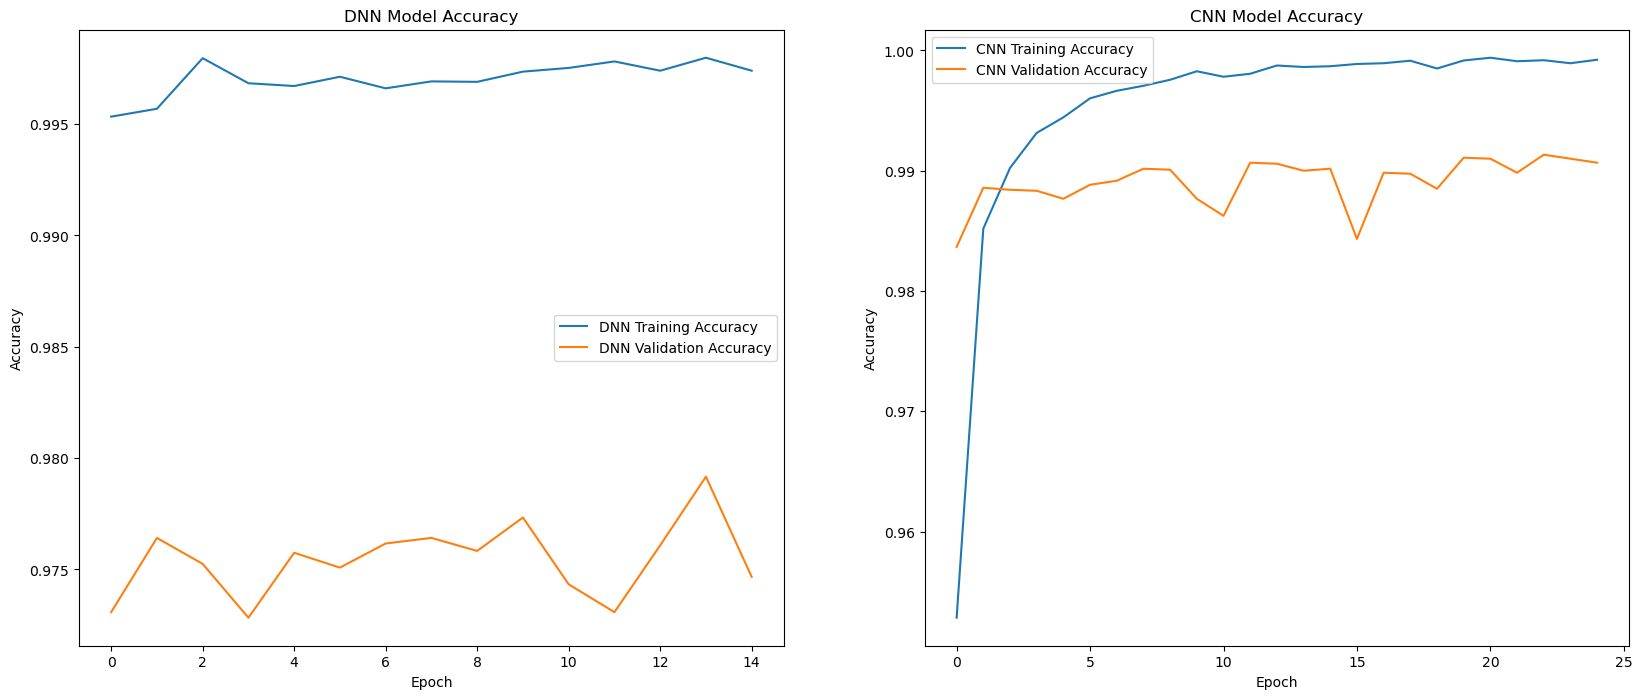

In [204]:
# training & validation accuracy for comparison

plt.figure(figsize=(20, 8))

# DNN accuracy plot
plt.subplot(1, 2, 1)
plt.plot(dnn_history.history['accuracy'], label='DNN Training Accuracy')
plt.plot(dnn_history.history['val_accuracy'], label='DNN Validation Accuracy')
plt.title('DNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# CNN accuracy plit
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='CNN Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.show()

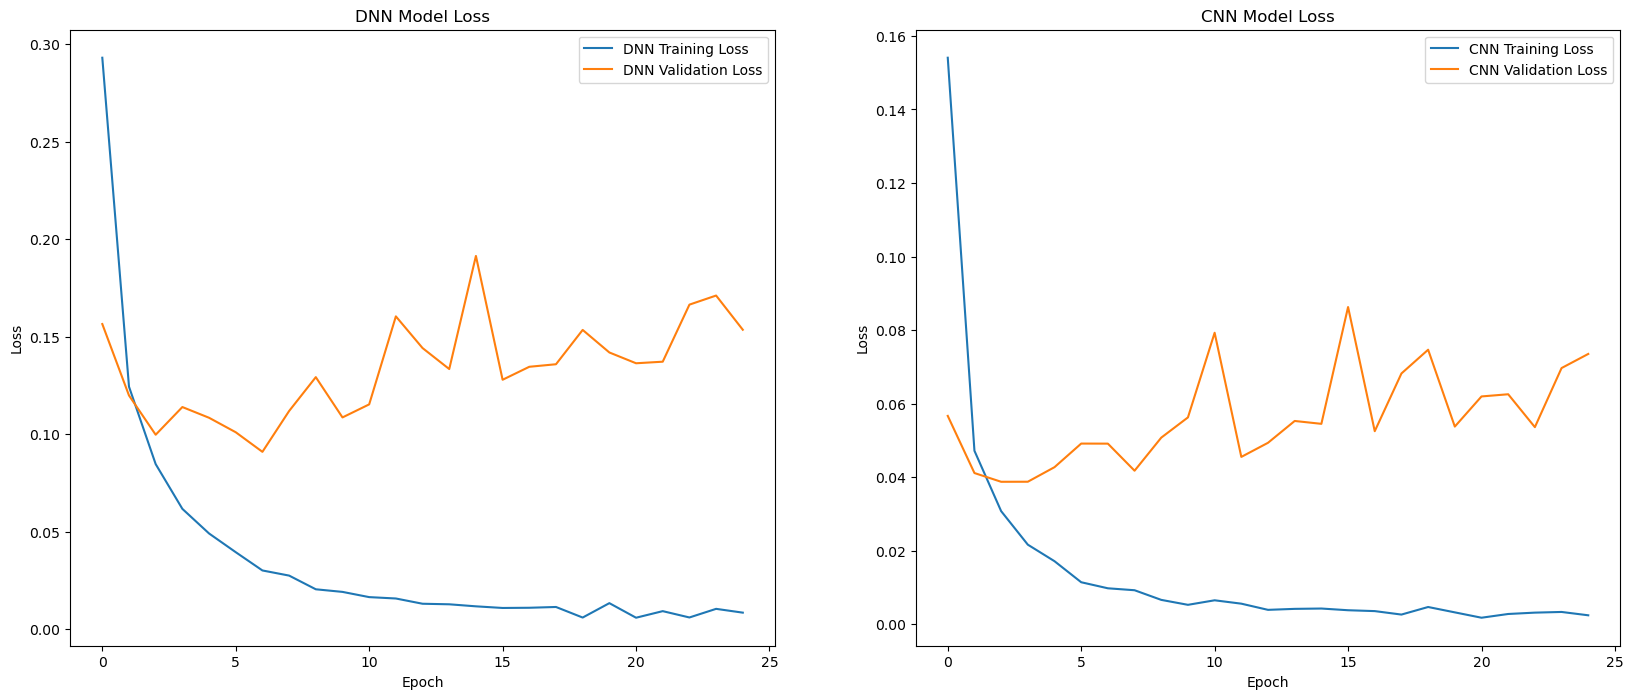

In [250]:
# training & validation loss comparison plot
plt.figure(figsize=(20, 8))

# DNN loss
plt.subplot(1, 2, 1)
plt.plot(dnn_history.history['loss'], label='DNN Training Loss')
plt.plot(dnn_history.history['val_loss'], label='DNN Validation Loss')
plt.title('DNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# CNN loss
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Training Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Validation Loss')
plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [201]:
# Comparison of misclassifications
dnn_incorrect = (dnn_predicted_classes != y_test)
cnn_incorrect = (cnn_predicted_classes != y_test)
print(f"DNN misclassified {np.sum(dnn_incorrect)} test samples")
print(f"CNN misclassified {np.sum(cnn_incorrect)} test samples")

DNN misclassified 238 test samples
CNN misclassified 88 test samples
